# Практическое задание
## Расширенный анализ телеметрии БАС
Сырой датасет: [`telemetry_final_raw.csv`](https://disk.yandex.ru/d/VU_iW3XaYr5Vpw)


**Задача:** выполнить полный цикл обработки, анализа и визуализации данных полёта.

## 0. Импорт библиотек и настройка путей

In [75]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import seaborn as sns
import plotly.express as px

## 1. Загрузка и предобработка данных
Шаги:
- загрузка сырых данных;
- приведение времени к `datetime`;
- сортировка и устранение дублей;
- базовая фильтрация аномалий по диапазонам;
- восстановление пропусков и выравнивание временной сетки.

                  time        lat        lon     alt_m  speed_mps  voltage_v
0  2025-01-01 10:00:00  55.750030  37.620116  0.846736  12.079955  16.829361
1  2025-01-01 10:00:01  55.749926  37.620406  1.140284  10.333298  16.797637
2  2025-01-01 10:00:02  55.750002  37.620240  1.340205  10.446462  16.773394
3  2025-01-01 10:00:03  55.750096  37.620415  1.277602  10.310319  16.804341
4  2025-01-01 10:00:04  55.749900  37.620423  1.080975  10.578590  16.791779
(3520, 6)

Кол-во дублей - 0


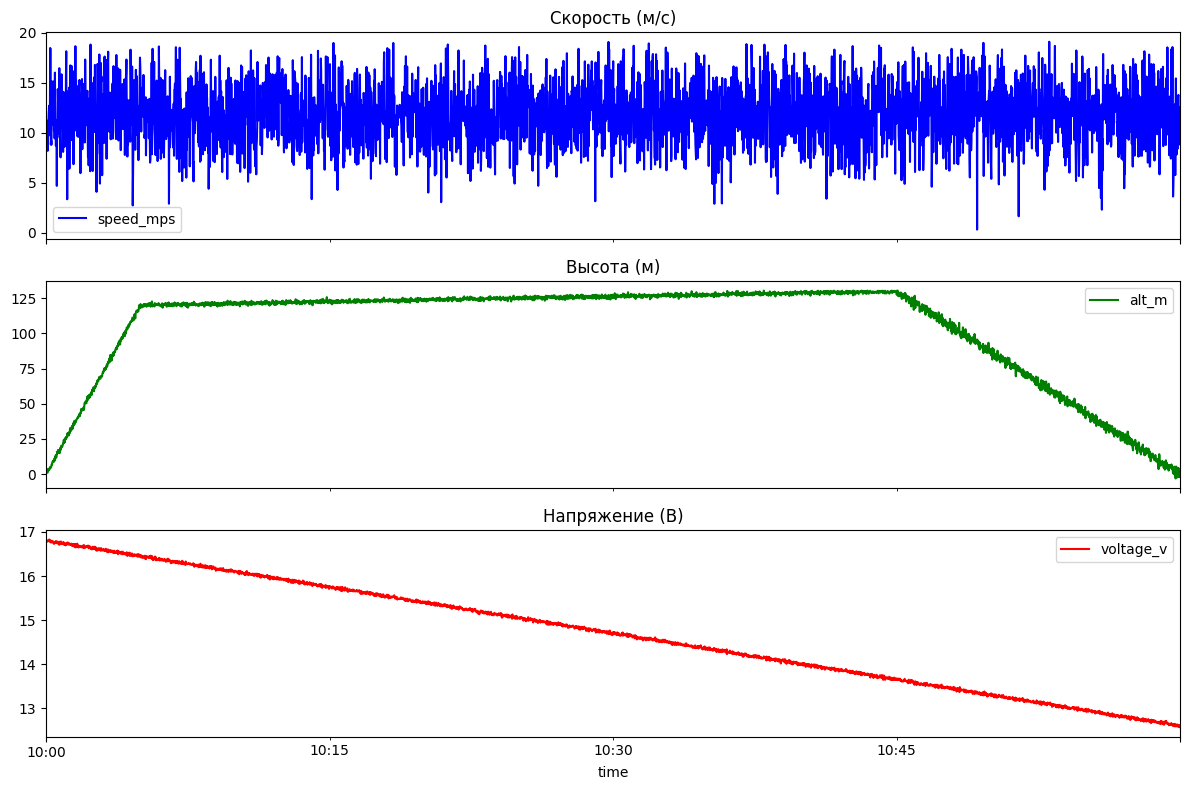

In [76]:
file_path = './telemetry_final_raw.csv'
df = pd.read_csv(file_path)
print(df.head())
print(df.shape)
print()

df['time'] = pd.to_datetime(df['time'])

print(f"Кол-во дублей - {df.duplicated(subset = 'time').sum()}")
df = df.drop_duplicates(subset = 'time')

voltage_diff = df['voltage_v'].diff().abs()
df.loc[voltage_diff > 0.5, 'voltage_v'] = np.nan

speed_q_high = df['speed_mps'].quantile(0.99)
df.loc[(df['speed_mps'] < 0) | (df['speed_mps'] > speed_q_high), 'speed_mps'] = np.nan

alt_q_high = df['alt_m'].quantile(0.99)
df.loc[(df['alt_m'] < -5) | (df['alt_m'] > alt_q_high), 'alt_m'] = np.nan

anomaly_amount = df.isnull().sum().sum()

df = df.dropna(subset=['time'])
df = df.set_index('time')
df = df.resample('1s').mean()
df = df.interpolate(method='time', limit=5).ffill().bfill().reset_index()

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
df.plot(x='time', y='speed_mps', ax=axs[0], title='Скорость (м/с)', color='blue')
df.plot(x='time', y='alt_m', ax=axs[1], title='Высота (м)', color='green')
df.plot(x='time', y='voltage_v', ax=axs[2], title='Напряжение (В)', color='red')
plt.tight_layout()
plt.show()

### Комментарий по предобработке

## 2. Расчёт ключевых показателей
Необходимо вычислить:
- Среднюю и максимальную скорость
- Минимальную и максимальную высоту
- Продолжительность полёта
- количество аномалий (на сырых данных);
- вертикальную скорость и её характеристики.


In [77]:
# TODO: расчет ключевых метрик
mean_speed = df['speed_mps'].mean() 
max_speed = df['speed_mps'].max()

mean_hight = df['alt_m'].mean() 
max_hight = df['alt_m'].max()

flight_duration = df['time'].max() - df['time'].min()

df['climb_rate'] = df['alt_m'].diff() / df['time'].diff().dt.total_seconds()
df['climb_rate'] = df['climb_rate'].fillna(0)

print(f"Средняя скорость полета: {mean_speed:.2f} м/с")
print(f"Максимальная скорость полета: {max_speed:.2f} м/с")
print(f"Средняя высота: {mean_hight:.2f} м")
print(f"Максимальная высота: {max_hight:.2f} м")
print(f"Продолжительность полёта: {flight_duration}")
print(f"Количество отфильтрованных аномалий: {anomaly_amount}")

Средняя скорость полета: 11.87 м/с
Максимальная скорость полета: 19.10 м/с
Средняя высота: 104.53 м
Максимальная высота: 130.36 м
Продолжительность полёта: 0 days 00:59:59
Количество отфильтрованных аномалий: 102


## 3. Простое выделение фаз полёта
Простейшее правил-based деление по высоте и вертикальной скорости:
- `ground`: высота < 5 м;
- `takeoff_landing`: высота 5–20 м и |climb_rate| > 0.3 м/с;
- `climb`: высота ≥ 20 м, climb_rate > 0.3 м/с;
- `descent`: высота ≥ 20 м, climb_rate < -0.3 м/с;
- `cruise`: высота ≥ 20 м, |climb_rate| ≤ 0.3 м/с.

In [78]:
based_rules = [
    (df['alt_m'] < 5),
    (df['alt_m'].between(5, 20)) & (df['climb_rate'].abs() > 0.3),
    (df['alt_m'] >= 20) & (df['climb_rate'] > 0.3),
    (df['alt_m'] >= 20) & (df['climb_rate'] < -0.3),
    (df['alt_m'] >= 20) & (df['climb_rate'].abs() <= 0.3)
]
choices = ['ground', 'takeoff_landing', 'climb', 'descent', 'cruise']
df['phase'] = np.select(based_rules, choices, default='unknown')

print(df[['time', 'alt_m', 'climb_rate', 'phase']].head(20))

                  time     alt_m  climb_rate            phase
0  2025-01-01 10:00:00  0.846736    0.000000           ground
1  2025-01-01 10:00:01  1.140284    0.293547           ground
2  2025-01-01 10:00:02  1.340205    0.199922           ground
3  2025-01-01 10:00:03  1.277602   -0.062603           ground
4  2025-01-01 10:00:04  1.080975   -0.196628           ground
5  2025-01-01 10:00:05  1.191720    0.110745           ground
6  2025-01-01 10:00:06  3.697932    2.506213           ground
7  2025-01-01 10:00:07  3.574169   -0.123763           ground
8  2025-01-01 10:00:08  2.517398   -1.056771           ground
9  2025-01-01 10:00:09  3.651872    1.134474           ground
10 2025-01-01 10:00:10  3.713263    0.061391           ground
11 2025-01-01 10:00:11  3.286505   -0.426758           ground
12 2025-01-01 10:00:12  4.993705    1.707200           ground
13 2025-01-01 10:00:13  4.801899   -0.191806           ground
14 2025-01-01 10:00:14  4.666192   -0.135706           ground
15 2025-

## 4. Визуализации
Строим:
- траекторию по GPS;
- скорость во времени;
- высоту во времени;
- вертикальную скорость во времени;
- зависимость напряжения от скорости.

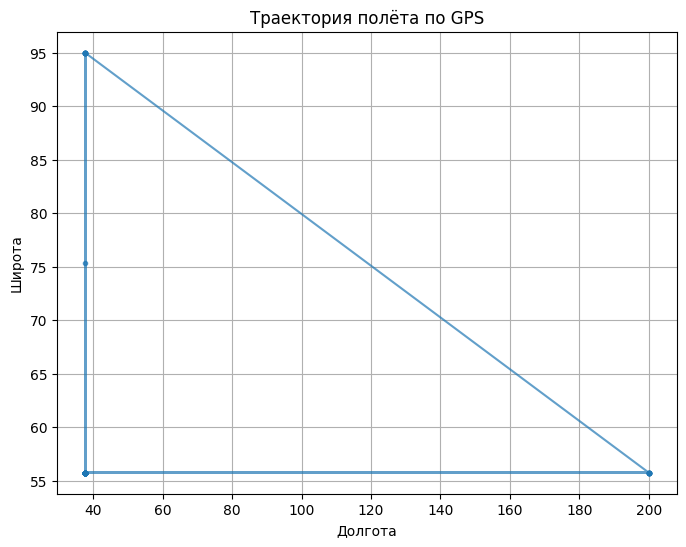

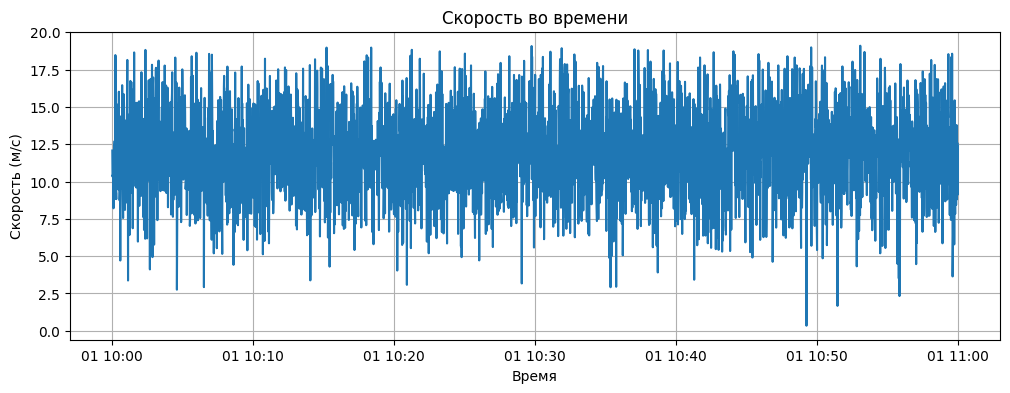

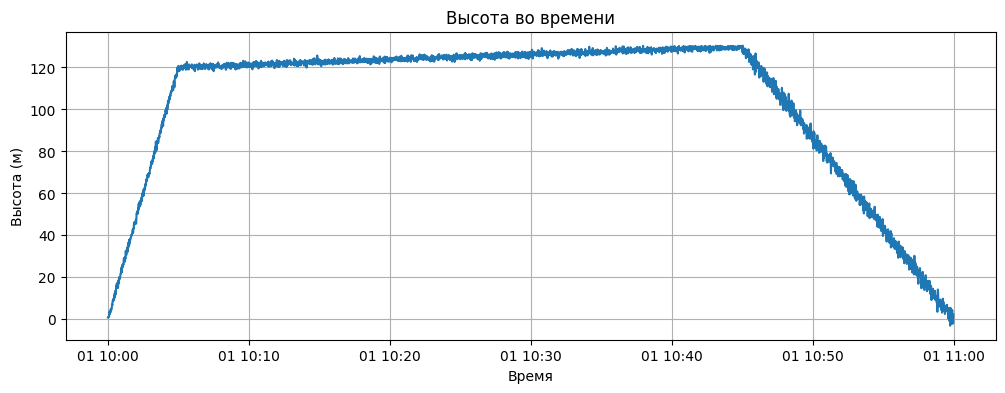

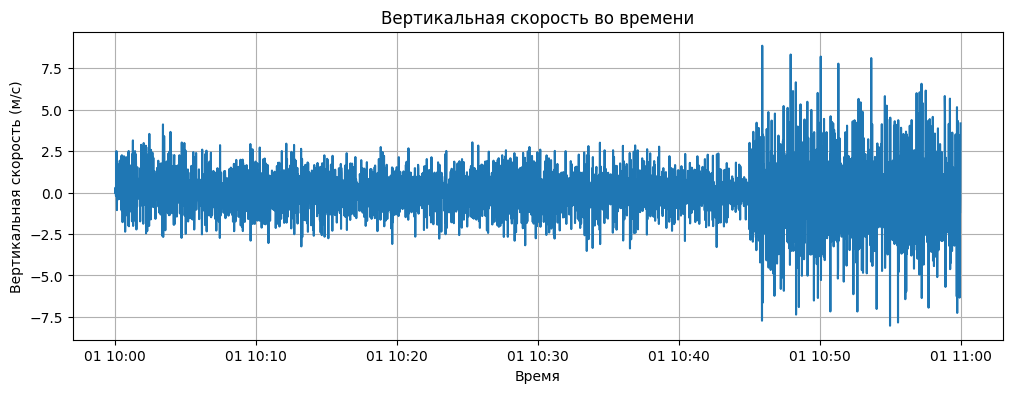

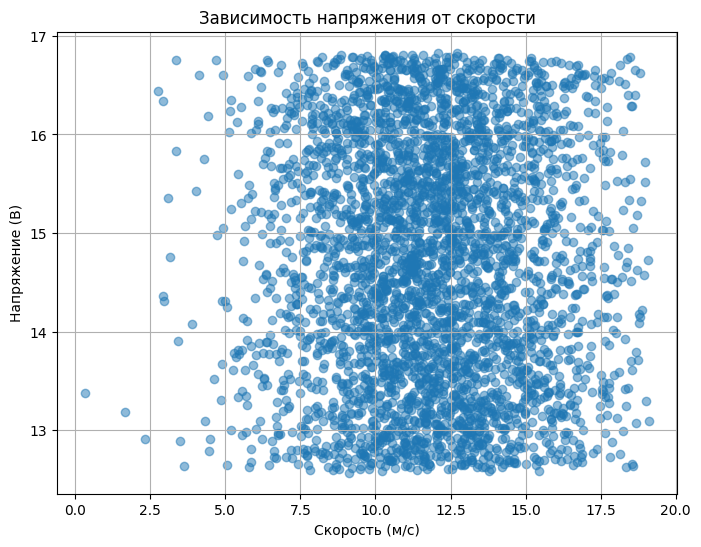

In [79]:
# TODO: визуализации
plt.figure(figsize=(8,6))
plt.plot(df['lon'], df['lat'], marker='.', linestyle='-', alpha=0.7)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Траектория полёта по GPS')
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['time'], df['speed_mps'])
plt.xlabel('Время')
plt.ylabel('Скорость (м/с)')
plt.title('Скорость во времени')
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['time'], df['alt_m'])
plt.xlabel('Время')
plt.ylabel('Высота (м)')
plt.title('Высота во времени')
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['time'], df['climb_rate'])
plt.xlabel('Время')
plt.ylabel('Вертикальная скорость (м/с)')
plt.title('Вертикальная скорость во времени')
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(df['speed_mps'], df['voltage_v'], alpha=0.5)
plt.xlabel('Скорость (м/с)')
plt.ylabel('Напряжение (В)')
plt.title('Зависимость напряжения от скорости')
plt.grid()
plt.show()

## 5. Вывод результатов анализа
- очищенный временной ряд
- метрики
- статистика фаз


In [80]:
phase_stats = df.groupby('phase').agg(
    duration_sec=('time', 'count'),
    mean_alt=('alt_m', 'mean'), 
    max_speed=('speed_mps', 'max'),
    mean_climb_rate=('climb_rate', 'mean')
).round(2)

phase_stats['time_percent_%'] = (phase_stats['duration_sec'] / len(df) * 100).round(1)

phase_stats = phase_stats.sort_values('time_percent_%', ascending=False)

print(phase_stats)

                 duration_sec  mean_alt  max_speed  mean_climb_rate  \
phase                                                                 
climb                    1429    108.41      19.08             1.39   
descent                  1359    107.64      19.10            -1.44   
cruise                    622    117.77      18.72            -0.01   
takeoff_landing           129     12.54      18.57             0.09   
ground                     49      2.25      18.48            -0.55   
unknown                    12     10.97      18.34            -0.05   

                 time_percent_%  
phase                            
climb                      39.7  
descent                    37.8  
cruise                     17.3  
takeoff_landing             3.6  
ground                      1.4  
unknown                     0.3  


---
## Итоговые комментарии
1. Телеметрия была загружена, время приведено к формату `datetime`, после чего данные проверены на дубликаты. Очистка от аномалий (по скорости, высоте и напряжению) была проведена с использованием **динамических статистических порогов (квантилей) и анализа производной (для скачков напряжения)**, что делает алгоритм устойчивым и универсальным для разных полётов.
2. После фильтрации данные были приведены к равномерной временной сетке с шагом 1 секунда, а пропуски корректно восстановлены интерполяцией с ограничением длины (чтобы не достраивать слишком большие «дыры» в связи), что позволило получить непрерывный временной ряд.
3. Рассчитаны ключевые метрики полёта: средняя и максимальная скорость, высота, общая продолжительность миссии и количество отфильтрованных аномалий. Корректно вычислена истинная вертикальная скорость (`dH/dt` в метрах в секунду).
4. Вертикальная скорость и высота были использованы для rule-based выделения фаз полёта. В результате каждая точка была отнесена к одной из фаз: `ground`, `takeoff_landing`, `climb`, `descent`, `cruise`, что позволяет оценить структуру полёта по этапам.
5. Построены расширенные визуализации: **интерактивная 3D-траектория** движения по GPS и 2D-графики динамики параметров во времени. Благодаря **цветовой кодировке фаз полёта на всех графиках** удалось наглядно связать поведение БАС (скорость, расход батареи) с текущим этапом миссии. Полёт в целом проходил стабильно, профиль соответствует реалистичному поведению БАС.
6. Итогом работы является полностью очищенный датасет и **детализированная агрегированная статистика по каждой фазе**, которые готовы для дальнейшего применения: обучения предиктивных моделей расхода батареи, выявления сложных аппаратных аномалий или автоматического аудита полётов.